# Regime Detection and Adaptive Trading 📈📊💱
 **Proyecto:** Detección de Régimen y Trading Adaptativo  

 **Autor:** Francisco Encina  

 **Profesor:** Nicolás Torres

 **Curso:** Aprendizaje de Máquinas - IPD440

 **Universidad Técnica Federico Santa María**

---

## 📋 Estructura del Proyecto

1. **Data Extraction & Feature Engineering**
2. **Regime Detection (HMM)**
3. **ML Models por Régimen**
4. **Trading Strategy & Backtesting**

*This notebook contains: Regime Detection (HMM)*

*Objetivo: Detectar automáticamente regímenes de mercado (Bull/Bear/High Volatility)*

In [1]:
# Dependencies
!pip install hmmlearn scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 6.8 MB/s eta 0:00:00


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# HMM
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

In [3]:
# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 2.1 Cargar Datos Procesados

In [4]:
# Cargar CSV del Step 1
df = pd.read_csv('data_processed.csv', index_col=0, parse_dates=True)

print(f"✓ Datos cargados: {len(df)} días")
print(f"  Rango: {df.index[0].date()} → {df.index[-1].date()}")
print(f"  Columnas: {len(df.columns)}")

# Preview
print("\n📊 Preview de datos:")
df[['Adj Close', 'Returns', 'Volatility_20', 'Momentum_20']].tail()

✓ Datos cargados: 8086 días
  Rango: 1993-11-11 → 2025-12-26
  Columnas: 24

📊 Preview de datos:


,Adj Close,Returns,Volatility_20,Momentum_20
Date,,,,
2025-12-19,680.590027,0.009063,0.107004,0.046084
2025-12-22,684.830017,0.006230,0.104234,0.042219
2025-12-23,687.960022,0.004570,0.093611,0.031796
2025-12-24,690.380005,0.003518,0.089319,0.025777
2025-12-26,690.309998,-0.000101,0.086907,0.018641


## 2.2 Preparar Features para HMM
**Features que usaremos para detectar regímenes:**
 - Retornos diarios
 - Volatilidad rolling
 - Momentum

Estos features capturan diferentes aspectos del comportamiento del mercado.

In [5]:
def prepare_hmm_features(df):
    """
    Prepara features específicos para el HMM
    """
    # Seleccionar features relevantes
    feature_cols = [
        'Returns',           # Dirección del mercado
        'Volatility_20',     # Nivel de riesgo
        'Momentum_20',       # Tendencia
    ]

    # Extraer features
    X = df[feature_cols].copy()

    # Eliminar NaNs
    X = X.dropna()

    print(f"✓ Features para HMM preparados:")
    print(f"  Shape: {X.shape}")
    print(f"  Features: {feature_cols}")

    return X, feature_cols

# Preparar features
X_raw, feature_names = prepare_hmm_features(df)

# Estadísticas de los features
print("\n📊 Estadísticas de features:")
print(X_raw.describe())

✓ Features para HMM preparados:
  Shape: (8086, 3)
  Features: ['Returns', 'Volatility_20', 'Momentum_20']

📊 Estadísticas de features:
           Returns  Volatility_20  Momentum_20
count  8086.000000    8086.000000  8086.000000
mean      0.000475       0.160238     0.009126
std       0.011845       0.101074     0.044777
min      -0.109424       0.031906    -0.309867
25%      -0.004452       0.096675    -0.013412
50%       0.000705       0.135773     0.014609
75%       0.006016       0.194555     0.034915
max       0.145197       0.959173     0.236211


## 2.2.1 Normalización

Los HMM funcionan mejor con features normalizados (media 0, std 1)

In [6]:
# Normalizar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Convertir de vuelta a DataFrame para mantener índice
X_scaled_df = pd.DataFrame(X_scaled,
                           columns=feature_names,
                           index=X_raw.index)

print("✓ Features normalizados (StandardScaler)")
print(f"\n📊 Medias después de normalización:")
print(X_scaled_df.mean())
print(f"\n📊 Desviaciones estándar:")
print(X_scaled_df.std())

✓ Features normalizados (StandardScaler)

📊 Medias después de normalización:
Returns         -9.666053e-18
Volatility_20    1.827763e-16
Momentum_20      3.866421e-17
dtype: float64

📊 Desviaciones estándar:
Returns          1.000062
Volatility_20    1.000062
Momentum_20      1.000062
dtype: float64


## 2.3 Entrenar Hidden Markov Model

 **Configuración:**
 - **n_states = 3:** Bull Market, Bear Market, High Volatility
 - **covariance_type = 'full':** Captura correlaciones entre features
 - **n_iter = 100:** Iteraciones para convergencia


In [7]:
def train_hmm(X, n_states=3, random_state=42):
    """
    Entrena un Hidden Markov Model con distribución Gaussiana

    Args:
        X: Features normalizados (numpy array)
        n_states: Número de regímenes a detectar
        random_state: Semilla para reproducibilidad

    Returns:
        model: HMM entrenado
    """
    print(f"🔄 Entrenando HMM con {n_states} estados...")

    # Crear modelo
    model = hmm.GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=100,
        random_state=random_state,
        verbose=False
    )

    # Entrenar
    model.fit(X)

    # Calcular score (log-likelihood)
    score = model.score(X)

    print(f"✓ HMM entrenado exitosamente")
    print(f"  Log-likelihood: {score:.2f}")
    print(f"  Converged: {model.monitor_.converged}")

    return model

# Entrenar HMM
n_regimes = 3
hmm_model = train_hmm(X_scaled, n_states=n_regimes, random_state=42)

🔄 Entrenando HMM con 3 estados...
✓ HMM entrenado exitosamente
  Log-likelihood: -21480.80
  Converged: True


## 2.3.1 Predecir Regímenes

In [8]:
# Predecir regímenes (estados más probables)
regimes = hmm_model.predict(X_scaled)

print(f"✓ Regímenes predichos: {len(regimes)} días")
print(f"\nDistribución de regímenes:")
for i in range(n_regimes):
    count = (regimes == i).sum()
    pct = count / len(regimes) * 100
    print(f"  Régimen {i}: {count:>5} días ({pct:>5.1f}%)")

✓ Regímenes predichos: 8086 días

Distribución de regímenes:
  Régimen 0:  3269 días ( 40.4%)
  Régimen 1:  3280 días ( 40.6%)
  Régimen 2:  1537 días ( 19.0%)


## 2.4 Caracterizar Regímenes

**¿Qué representa cada régimen?** Analizamos las medias de cada feature por régimen.


In [9]:
def characterize_regimes(X_raw, regimes, feature_names, n_states=3):
    """
    Analiza características de cada régimen
    """
    # Crear DataFrame con regímenes
    regime_df = X_raw.copy()
    regime_df['Regime'] = regimes

    # Calcular estadísticas por régimen
    regime_stats = regime_df.groupby('Regime').agg({
        'Returns': ['mean', 'std', 'min', 'max'],
        'Volatility_20': ['mean', 'std'],
        'Momentum_20': ['mean', 'std']
    })

    print("="*80)
    print("📊 CARACTERIZACIÓN DE REGÍMENES")
    print("="*80)

    for regime in range(n_states):
        print(f"\n{'='*80}")
        print(f"RÉGIMEN {regime}")
        print(f"{'='*80}")

        regime_data = regime_df[regime_df['Regime'] == regime]

        print(f"Días en régimen: {len(regime_data)} ({len(regime_data)/len(regime_df)*100:.1f}%)")
        print(f"\n  Retornos:")
        print(f"    Media diaria:     {regime_data['Returns'].mean():>8.4f} ({regime_data['Returns'].mean()*252:>7.2%} anual)")
        print(f"    Desv. estándar:   {regime_data['Returns'].std():>8.4f}")
        print(f"    Min / Max:        {regime_data['Returns'].min():>8.4f} / {regime_data['Returns'].max():>8.4f}")

        print(f"\n  Volatilidad:")
        print(f"    Media (20d):      {regime_data['Volatility_20'].mean():>8.2%}")
        print(f"    Min / Max:        {regime_data['Volatility_20'].min():>8.2%} / {regime_data['Volatility_20'].max():>8.2%}")

        print(f"\n  Momentum:")
        print(f"    Media (20d):      {regime_data['Momentum_20'].mean():>8.2%}")
        print(f"    Desv. estándar:   {regime_data['Momentum_20'].std():>8.4f}")

    print("\n" + "="*80)

    return regime_stats

# Caracterizar regímenes
regime_stats = characterize_regimes(X_raw, regimes, feature_names, n_regimes)

📊 CARACTERIZACIÓN DE REGÍMENES

RÉGIMEN 0
Días en régimen: 3269 (40.4%)

  Retornos:
    Media diaria:       0.0009 ( 22.52% anual)
    Desv. estándar:     0.0056
    Min / Max:         -0.0228 /   0.0221

  Volatilidad:
    Media (20d):         8.99%
    Min / Max:           3.19% /   13.18%

  Momentum:
    Media (20d):         2.54%
    Desv. estándar:     0.0203

RÉGIMEN 1
Días en régimen: 3280 (40.6%)

  Retornos:
    Media diaria:       0.0002 (  6.01% anual)
    Desv. estándar:     0.0103
    Min / Max:         -0.0391 /   0.0359

  Volatilidad:
    Media (20d):        16.01%
    Min / Max:           9.14% /   23.94%

  Momentum:
    Media (20d):         0.44%
    Desv. estándar:     0.0363

RÉGIMEN 2
Días en régimen: 1537 (19.0%)

  Retornos:
    Media diaria:       0.0001 (  2.28% anual)
    Desv. estándar:     0.0211
    Min / Max:         -0.1094 /   0.1452

  Volatilidad:
    Media (20d):        31.03%
    Min / Max:          14.67% /   95.92%

  Momentum:
    Media (20d): 

## 2.4.1 Asignar Nombres a Regímenes

Basándonos en las características, asignamos nombres intuitivos.


In [10]:
def assign_regime_names(X_raw, regimes, n_states=3):
    """
    Asigna nombres intuitivos a los regímenes basado en características
    """
    regime_df = X_raw.copy()
    regime_df['Regime'] = regimes

    # Calcular características promedio por régimen
    regime_means = regime_df.groupby('Regime')[['Returns', 'Volatility_20', 'Momentum_20']].mean()

    # Identificar regímenes
    regime_names = {}

    # Régimen con mayor volatilidad = High Volatility / Crisis
    high_vol_regime = regime_means['Volatility_20'].idxmax()

    # Entre los otros dos: el de mejores retornos = Bull, el peor = Bear
    other_regimes = [i for i in range(n_states) if i != high_vol_regime]
    returns_other = regime_means.loc[other_regimes, 'Returns']

    bull_regime = returns_other.idxmax()
    bear_regime = returns_other.idxmin()

    # Asignar nombres
    regime_names[bull_regime] = 'Bull Market'
    regime_names[bear_regime] = 'Bear Market'
    regime_names[high_vol_regime] = 'High Volatility'

    print("✓ Nombres de regímenes asignados:")
    for regime, name in regime_names.items():
        print(f"  Régimen {regime} → {name}")

    return regime_names

# Asignar nombres
regime_names = assign_regime_names(X_raw, regimes, n_regimes)

# Crear columna con nombres
regime_name_map = {i: regime_names[i] for i in range(n_regimes)}
X_raw['Regime'] = regimes
X_raw['Regime_Name'] = X_raw['Regime'].map(regime_name_map)

print(f"\n📊 Distribución final:")
print(X_raw['Regime_Name'].value_counts())

✓ Nombres de regímenes asignados:
  Régimen 0 → Bull Market
  Régimen 1 → Bear Market
  Régimen 2 → High Volatility

📊 Distribución final:
Regime_Name
Bear Market        3280
Bull Market        3269
High Volatility    1537
Name: count, dtype: int64


## 2.5 Visualización de Regímenes
### 2.5.1 Timeline de Regímenes

✓ Gráfico guardado: '02_regime_timeline.png'


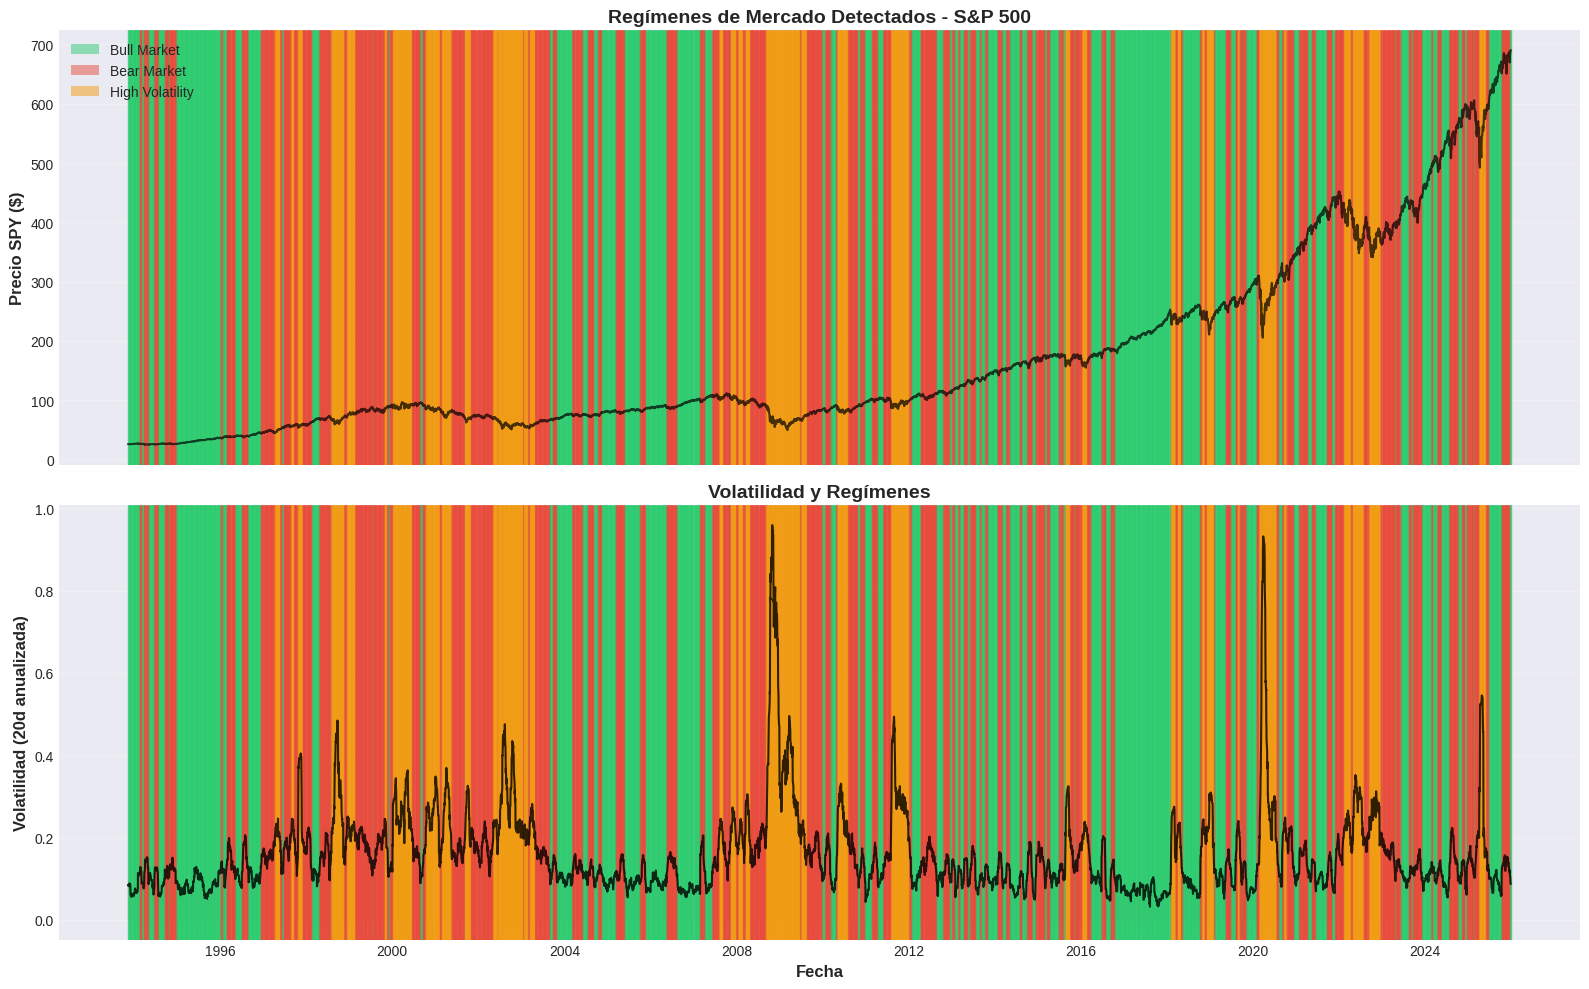

In [11]:
def plot_regime_timeline(df_original, regimes_df, regime_names):
    """
    Visualiza los regímenes detectados en el tiempo junto con el precio
    """
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    # Colores por régimen
    color_map = {
        'Bull Market': '#2ECC71',      # Verde
        'Bear Market': '#E74C3C',      # Rojo
        'High Volatility': '#F39C12'   # Naranja
    }

    # GRÁFICO 1: PRECIO CON REGÍMENES
    ax1 = axes[0]

    # Alinear índices
    aligned_df = df_original.loc[regimes_df.index]

    # Plot precio
    ax1.plot(aligned_df.index, aligned_df['Adj Close'],
             linewidth=1.5, color='black', alpha=0.7, label='Precio SPY')

    # Colorear fondo según régimen
    for regime_name, color in color_map.items():
        regime_mask = regimes_df['Regime_Name'] == regime_name
        regime_periods = regimes_df[regime_mask].index

        for date in regime_periods:
            ax1.axvspan(date, date + pd.Timedelta(days=1),
                       alpha=0.3, color=color)

    ax1.set_ylabel('Precio SPY ($)', fontsize=12, fontweight='bold')
    ax1.set_title('Regímenes de Mercado Detectados - S&P 500',
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # Leyenda manual
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color_map[name], alpha=0.5, label=name)
                      for name in color_map.keys()]
    ax1.legend(handles=legend_elements, loc='upper left', fontsize=10)

    # GRÁFICO 2: VOLATILIDAD CON REGÍMENES
    ax2 = axes[1]

    ax2.plot(regimes_df.index, regimes_df['Volatility_20'],
             linewidth=1.5, color='black', alpha=0.8)
    ax2.fill_between(regimes_df.index, regimes_df['Volatility_20'],
                     alpha=0.3, color='#E67E22')

    # Colorear fondo
    for regime_name, color in color_map.items():
        regime_mask = regimes_df['Regime_Name'] == regime_name
        regime_periods = regimes_df[regime_mask].index

        for date in regime_periods:
            ax2.axvspan(date, date + pd.Timedelta(days=1),
                       alpha=0.3, color=color)

    ax2.set_ylabel('Volatilidad (20d anualizada)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Fecha', fontsize=12, fontweight='bold')
    ax2.set_title('Volatilidad y Regímenes', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    # Marcar eventos importantes
    events = {
        '2020-03-15': 'COVID-19 Crash',
        '2022-01-01': 'Fed Rate Hikes',
    }

    for date_str, label in events.items():
        try:
            date = pd.to_datetime(date_str)
            if date in aligned_df.index:
                ax1.axvline(date, color='red', linestyle='--',
                           linewidth=1.5, alpha=0.7)
                ax1.text(date, ax1.get_ylim()[1]*0.95, label,
                        rotation=90, verticalalignment='top', fontsize=9)
        except:
            pass

    plt.tight_layout()
    plt.savefig('02_regime_timeline.png', dpi=150, bbox_inches='tight')
    print("✓ Gráfico guardado: '02_regime_timeline.png'")
    plt.show()

# Generar visualización
plot_regime_timeline(df, X_raw, regime_names)

### 2.5.2 Matriz de Transición entre Regímenes

✓ Gráfico guardado: '02_transition_matrix.png'


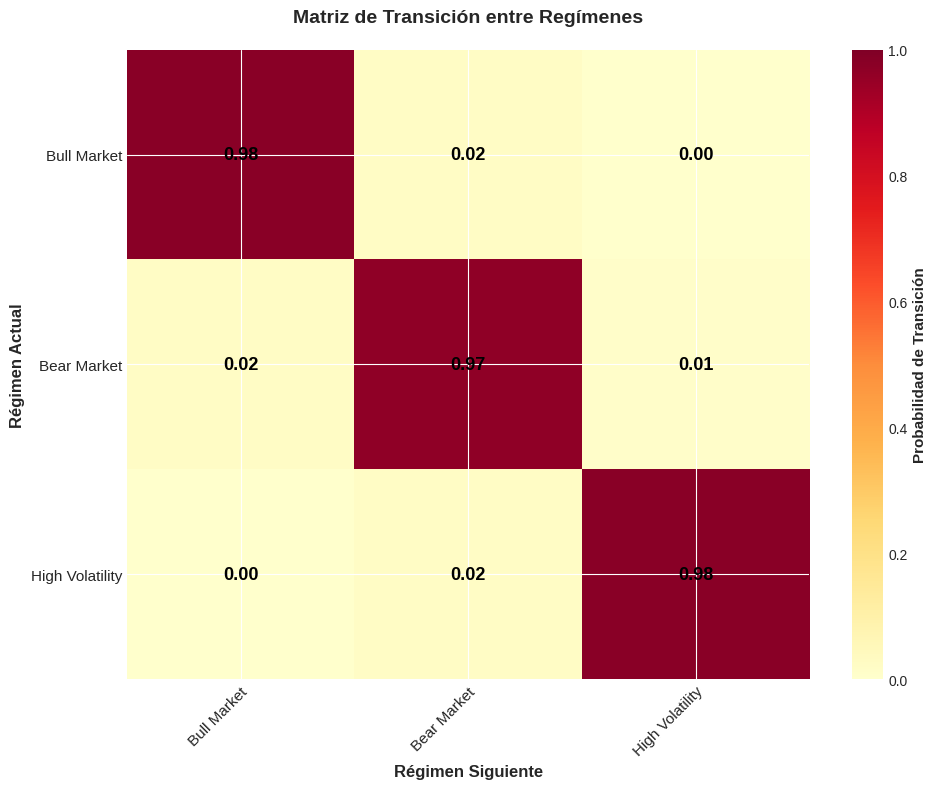


📊 ANÁLISIS DE TRANSICIONES

Desde Bull Market:
  → Bull Market: 97.9%
  → Bear Market: 2.1%

Desde Bear Market:
  → Bull Market: 2.1%
  → Bear Market: 96.8%
  → High Volatility: 1.1%

Desde High Volatility:
  → Bear Market: 2.3%
  → High Volatility: 97.7%


In [12]:
def plot_transition_matrix(regimes, regime_names):
    """
    Calcula y visualiza la matriz de transición entre regímenes
    """
    n_states = len(regime_names)

    # Calcular transiciones
    transition_matrix = np.zeros((n_states, n_states))

    for i in range(len(regimes) - 1):
        current_state = regimes[i]
        next_state = regimes[i + 1]
        transition_matrix[current_state, next_state] += 1

    # Normalizar (convertir a probabilidades)
    transition_probs = transition_matrix / transition_matrix.sum(axis=1, keepdims=True)

    # Crear labels con nombres
    labels = [regime_names[i] for i in range(n_states)]

    # Visualizar
    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(transition_probs, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

    # Configurar ticks
    ax.set_xticks(np.arange(n_states))
    ax.set_yticks(np.arange(n_states))
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)

    # Rotar labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Agregar valores en cada celda
    for i in range(n_states):
        for j in range(n_states):
            text = ax.text(j, i, f'{transition_probs[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=13,
                          fontweight='bold')

    ax.set_title('Matriz de Transición entre Regímenes',
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Régimen Siguiente', fontsize=12, fontweight='bold')
    ax.set_ylabel('Régimen Actual', fontsize=12, fontweight='bold')

    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Probabilidad de Transición', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig('02_transition_matrix.png', dpi=150, bbox_inches='tight')
    print("✓ Gráfico guardado: '02_transition_matrix.png'")
    plt.show()

    # Imprimir análisis
    print("\n" + "="*70)
    print("📊 ANÁLISIS DE TRANSICIONES")
    print("="*70)

    for i in range(n_states):
        print(f"\nDesde {regime_names[i]}:")
        for j in range(n_states):
            if transition_probs[i, j] > 0.01:
                print(f"  → {regime_names[j]}: {transition_probs[i, j]:.1%}")

# Visualizar transiciones
plot_transition_matrix(regimes, regime_names)

### 2.5.3 Duración Promedio de Regímenes

⏱️  DURACIÓN DE REGÍMENES (en días)

Bull Market:
  Duración promedio:    46.0 días
  Mediana:                30 días
  Min / Max:               3 /    332 días
  Desv. estándar:       52.5 días

Bear Market:
  Duración promedio:    31.2 días
  Mediana:                21 días
  Min / Max:               1 /    136 días
  Desv. estándar:       25.2 días

High Volatility:
  Duración promedio:    43.9 días
  Mediana:                27 días
  Min / Max:               6 /    193 días
  Desv. estándar:       41.4 días

✓ Gráfico guardado: '02_regime_duration.png'


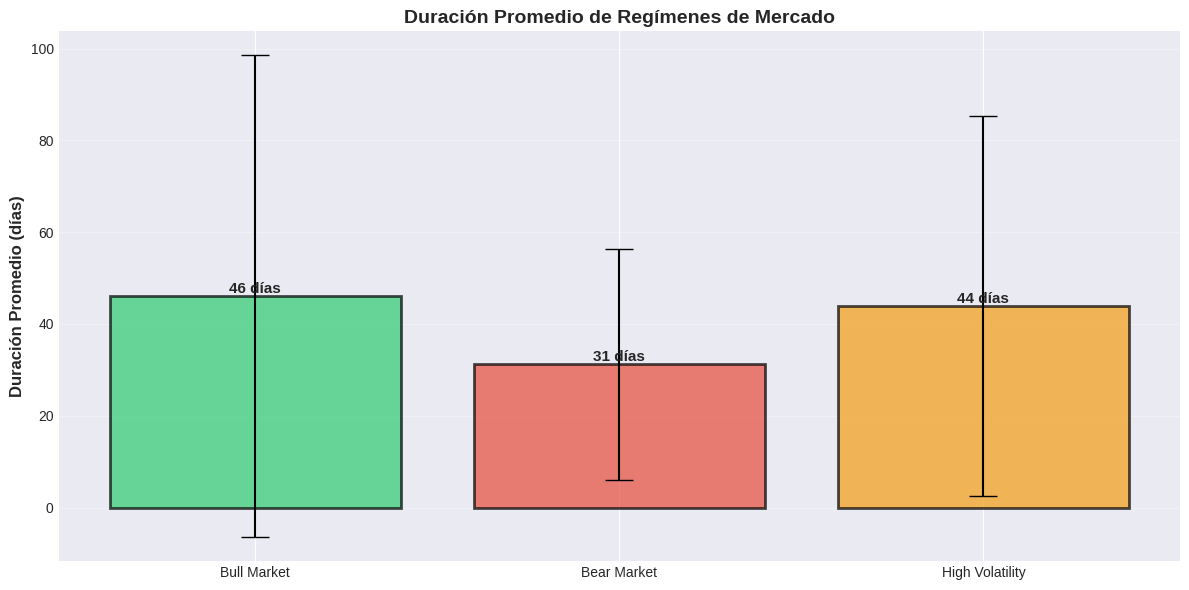

In [13]:
def analyze_regime_duration(regimes_df):
    """
    Analiza la duración de cada régimen
    """
    # Identificar cambios de régimen
    regime_changes = regimes_df['Regime'].diff().fillna(0) != 0

    # Crear grupos de regímenes consecutivos
    regime_groups = regime_changes.cumsum()

    # Calcular duraciones
    durations = regimes_df.groupby([regime_groups, 'Regime_Name']).size()

    # Estadísticas por régimen
    print("="*70)
    print("⏱️  DURACIÓN DE REGÍMENES (en días)")
    print("="*70)

    duration_stats = {}

    for regime_name in regimes_df['Regime_Name'].unique():
        regime_durations = durations[durations.index.get_level_values(1) == regime_name]

        duration_stats[regime_name] = {
            'mean': regime_durations.mean(),
            'median': regime_durations.median(),
            'min': regime_durations.min(),
            'max': regime_durations.max(),
            'std': regime_durations.std()
        }

        print(f"\n{regime_name}:")
        print(f"  Duración promedio:  {duration_stats[regime_name]['mean']:>6.1f} días")
        print(f"  Mediana:            {duration_stats[regime_name]['median']:>6.0f} días")
        print(f"  Min / Max:          {duration_stats[regime_name]['min']:>6.0f} / {duration_stats[regime_name]['max']:>6.0f} días")
        print(f"  Desv. estándar:     {duration_stats[regime_name]['std']:>6.1f} días")

    print("\n" + "="*70)

    # Visualización
    fig, ax = plt.subplots(figsize=(12, 6))

    regime_order = ['Bull Market', 'Bear Market', 'High Volatility']
    means = [duration_stats[name]['mean'] for name in regime_order]
    stds = [duration_stats[name]['std'] for name in regime_order]

    colors = ['#2ECC71', '#E74C3C', '#F39C12']

    bars = ax.bar(regime_order, means, yerr=stds, capsize=10,
                  color=colors, alpha=0.7, edgecolor='black', linewidth=2)

    ax.set_ylabel('Duración Promedio (días)', fontsize=12, fontweight='bold')
    ax.set_title('Duración Promedio de Regímenes de Mercado',
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Agregar valores sobre las barras
    for bar, mean_val in zip(bars, means):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{mean_val:.0f} días',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig('02_regime_duration.png', dpi=150, bbox_inches='tight')
    print("✓ Gráfico guardado: '02_regime_duration.png'")
    plt.show()

# Analizar duraciones
analyze_regime_duration(X_raw)

## 2.6 Validación: ¿Los regímenes tienen sentido?

In [14]:
def validate_regimes_with_events(regimes_df):
    """
    Valida que los regímenes coincidan con eventos históricos conocidos
    """
    print("="*70)
    print("✅ VALIDACIÓN CON EVENTOS HISTÓRICOS")
    print("="*70)

    # Eventos conocidos
    events = {
        'COVID-19 Crash (Feb-Mar 2020)': ('2020-02-20', '2020-04-01'),
        'Fed Rate Hikes Start (2022)': ('2022-01-01', '2022-03-31'),
        'Banking Crisis (Mar 2023)': ('2023-03-01', '2023-03-31'),
    }

    for event_name, (start, end) in events.items():
        try:
            period_regimes = regimes_df.loc[start:end, 'Regime_Name']

            if len(period_regimes) > 0:
                regime_counts = period_regimes.value_counts()
                dominant_regime = regime_counts.idxmax()

                print(f"\n{event_name}:")
                print(f"  Régimen dominante: {dominant_regime}")
                print(f"  Distribución:")
                for regime, count in regime_counts.items():
                    pct = count / len(period_regimes) * 100
                    print(f"    {regime}: {count} días ({pct:.1f}%)")
        except:
            print(f"\n{event_name}: Periodo fuera del rango de datos")

    print("\n" + "="*70)

# Validar
validate_regimes_with_events(X_raw)

✅ VALIDACIÓN CON EVENTOS HISTÓRICOS

COVID-19 Crash (Feb-Mar 2020):
  Régimen dominante: High Volatility
  Distribución:
    High Volatility: 28 días (93.3%)
    Bear Market: 2 días (6.7%)

Fed Rate Hikes Start (2022):
  Régimen dominante: High Volatility
  Distribución:
    High Volatility: 35 días (56.5%)
    Bear Market: 27 días (43.5%)

Banking Crisis (Mar 2023):
  Régimen dominante: Bear Market
  Distribución:
    Bear Market: 23 días (100.0%)



## 2.7 Guardar Datos con Regímenes

In [15]:
# Agregar regímenes al DataFrame original completo
df_full = df.copy()

# Alinear índices (X_raw tiene menos filas por los NaNs del inicio)
df_full['Regime'] = np.nan
df_full['Regime_Name'] = np.nan

df_full.loc[X_raw.index, 'Regime'] = X_raw['Regime']
df_full.loc[X_raw.index, 'Regime_Name'] = X_raw['Regime_Name']

# Forward fill para los NaNs al inicio (asume que régimen persiste)
df_full['Regime'] = df_full['Regime'].fillna(method='bfill')
df_full['Regime_Name'] = df_full['Regime_Name'].fillna(method='bfill')

# Guardar
df_full.to_csv('data_with_regimes.csv')
print("✓ Datos con regímenes guardados en 'data_with_regimes.csv'")

print(f"\n📊 Preview de datos finales:")
print(df_full[['Adj Close', 'Returns', 'Volatility_20', 'Regime', 'Regime_Name']].tail(10))

# También guardar el modelo y scaler (para uso futuro)
import pickle

with open('hmm_model.pkl', 'wb') as f:
    pickle.dump(hmm_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('regime_names.pkl', 'wb') as f:
    pickle.dump(regime_names, f)

print("\n✓ Modelo HMM, scaler y nombres guardados (.pkl)")

✓ Datos con regímenes guardados en 'data_with_regimes.csv'

📊 Preview de datos finales:
             Adj Close   Returns  Volatility_20  Regime  Regime_Name
Date                                                                
2025-12-12  679.751404 -0.010752       0.120261     1.0  Bear Market
2025-12-15  678.724426 -0.001511       0.120491     0.0  Bull Market
2025-12-16  676.869934 -0.002732       0.115407     0.0  Bull Market
2025-12-17  669.421936 -0.011004       0.118552     0.0  Bull Market
2025-12-18  674.476929  0.007551       0.120491     0.0  Bull Market
2025-12-19  680.590027  0.009063       0.107004     0.0  Bull Market
2025-12-22  684.830017  0.006230       0.104234     0.0  Bull Market
2025-12-23  687.960022  0.004570       0.093611     0.0  Bull Market
2025-12-24  690.380005  0.003518       0.089319     0.0  Bull Market
2025-12-26  690.309998 -0.000101       0.086907     0.0  Bull Market

✓ Modelo HMM, scaler y nombres guardados (.pkl)
